In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from IPython.display import FileLink
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def find_dataset_path(target_name):
    for root, dirs, _ in os.walk('/kaggle/input'):
        if target_name in dirs:
            full_path = os.path.join(root, target_name)
            if os.listdir(full_path):
                return full_path
    return None

train_path = find_dataset_path("FER_preprocessed_train")
test_path = find_dataset_path("preprocessed_test")

if train_path and test_path:
    print(f"dataset found successfully.\ntrain: {train_path}\ntest: {test_path}")
else:
    print("error: could not find dataset directories.")

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
        transforms.RandomHorizontalFlip(), 
        transforms.RandomRotation(15),      
        transforms.ColorJitter(brightness=0.2, contrast=0.2), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# veri setlerinin yuklenmesi
train_dataset = datasets.ImageFolder(root=train_path, transform=data_transforms['train'])
test_dataset = datasets.ImageFolder(root=test_path, transform=data_transforms['val'])

#burayı 128e cektim cunku t4x2 kullanıyorum
train_loader = DataLoader(
    train_dataset, 
    batch_size=128, 
    shuffle=True, 
    num_workers=3,      # 3 çekirdek veriyi hazırlar
    pin_memory=True     # GPU'ya veri transferini hızlandırır
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=128, 
    shuffle=False, 
    num_workers=3,
    pin_memory=True
)
class_names = train_dataset.classes
num_classes = len(class_names)
print(f"classes: {class_names}")

dataset found successfully.
train: /kaggle/input/datasets/hamdimohamed22/fer-2013-dataset-resized-and-augmented/FER_preprocessed_train
test: /kaggle/input/datasets/hamdimohamed22/fer-2013-dataset-resized-and-augmented/preprocessed_test
classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


visualizing random samples from the training set:


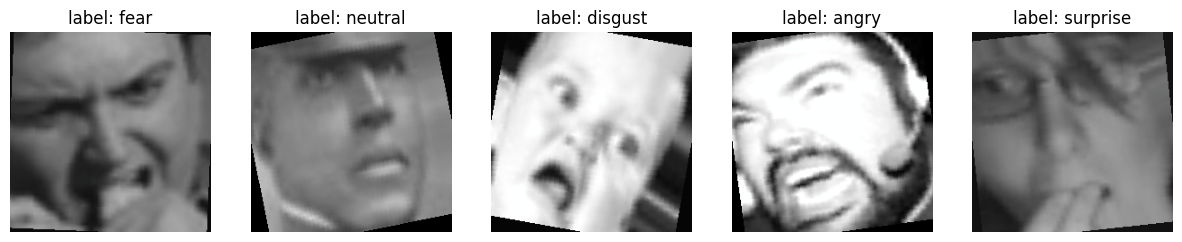


dataset distribution statistics:


,emotion,train_count,test_count
0,angry,7200,958
1,disgust,7200,111
2,fear,7200,1024
3,happy,7215,1774
4,neutral,7200,1233
5,sad,7200,1247
6,surprise,7200,831


In [2]:
#veri setini tanıtma bloğu
def visualize_samples(dataset, num_samples=5):
    plt.figure(figsize=(15, 5))
    random_indices = np.random.randint(0, len(dataset), num_samples)
    for i, idx in enumerate(random_indices):
        image, label = dataset[idx]
        image = image.numpy().transpose((1, 2, 0))
        # gorsellestirme icin normalizasyonu geri alma
        image = np.clip(image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image)
        plt.title(f"label: {class_names[label]}")
        plt.axis('off')
    plt.show()

print("visualizing random samples from the training set:")
visualize_samples(train_dataset)

# sinif dagilim analizi
data_info = {
    "emotion": class_names,
    "train_count": [len([x for x in train_dataset.targets if x == i]) for i in range(num_classes)],
    "test_count": [len([x for x in test_dataset.targets if x == i]) for i in range(num_classes)]
}
df_stats = pd.DataFrame(data_info)
print("\ndataset distribution statistics:")
display(df_stats)

In [3]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

num_classes = 7
num_epochs = 100
patience = 15

# Yolu elle yazmıyoruz, Python'a tüm Kaggle klasörlerini taratıyoruz:
checkpoint_load_path = ""
for root, dirs, files in os.walk('/kaggle/input'):
    if 'convnext_last_checkpoint.pth' in files:
        checkpoint_load_path = os.path.join(root, 'convnext_last_checkpoint.pth')
        print(f"!!! DOSYA BULUNDU: Gerçek yol -> {checkpoint_load_path}")
        break

if not checkpoint_load_path:
    raise FileNotFoundError("KAGGLE HATASI: Dataset tam baglanmamis.")# Yeni kayıtların yapılacağı yer
best_model_path = "/kaggle/working/convnext_best_model.pth"
last_checkpoint_path = "/kaggle/working/convnext_last_checkpoint.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

targets = train_dataset.targets
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(targets), y=targets)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

model = models.convnext_tiny(weights='DEFAULT')
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

#checki okumadı garanti olsun
start_epoch = 0
best_val_acc = 0.0

if checkpoint_load_path and os.path.exists(checkpoint_load_path):
    print(f"\n[!] Kayit yukleniyor: {checkpoint_load_path}")
    checkpoint = torch.load(checkpoint_load_path, map_location=device)
    
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        # --- GPU ISIMLENDIRME UYUMSUZLUGUNU COZEN KISIM ---
        state_dict = checkpoint['model_state_dict']
        new_state_dict = {}
        for k, v in state_dict.items():
            if hasattr(model, 'module') and not k.startswith('module.'):
                new_state_dict['module.' + k] = v
            elif not hasattr(model, 'module') and k.startswith('module.'):
                new_state_dict[k.replace('module.', '')] = v
            else:
                new_state_dict[k] = v
                
        model.load_state_dict(new_state_dict)
        # --------------------------------------------------
        
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_acc = checkpoint['best_val_acc']
        print(f"[*] Basarili! {start_epoch + 1}. epochtan devam ediliyor.")
        print(f"[*] Yuklenen Mevcut Rekor: %{best_val_acc:.2f}\n")
    else:
        model.load_state_dict(checkpoint)
        print("[!] Eski format model yuklendi.\n")
else:
    print("\n[?] Uyari: Checkpoint bulunamadi veya yol hatali.\n")
early_stop_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

#eğitim
for epoch in range(start_epoch, num_epochs):
    start_time = time.time()
    
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total

    model.eval()
    val_correct, val_total, val_running_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    epoch_time = time.time() - start_time
    
    print("-" * 30)
    print(f"Epoch {epoch+1}/{num_epochs} bitti ({epoch_time:.1f} sn)")
    print(f"Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: %{train_acc:.2f}")
    print(f"Val Loss: {val_running_loss/len(test_loader):.4f} | Val Acc: %{val_acc:.2f}")
    
    scheduler.step()

    # Her epoch sonu kaydet (Kaggle kapansa bile buradaki son bilgi kalir)
    checkpoint_paket = {
        'epoch': epoch,
        'model_state_dict': model.module.state_dict() if hasattr(model, 'module') else model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_acc': best_val_acc
    }
    torch.save(checkpoint_paket, last_checkpoint_path)

    # En iyi modeli kaydet
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        checkpoint_paket['best_val_acc'] = best_val_acc
        torch.save(checkpoint_paket, best_model_path) 
        print(f">>> YENI REKOR KAYDEDILDI: %{best_val_acc:.2f}")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(f"Gelisim yok. Patience: {early_stop_counter}/{patience}")

    if early_stop_counter >= patience:
        print("Erken durdurma (Early Stopping) tetiklendi.")
        break
    print("-" * 30)

!!! DOSYA BULUNDU: Gerçek yol -> /kaggle/input/datasets/nazarkg/ondokuzsubat/convnext_last_checkpoint.pth
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 178MB/s]



[!] Kayit yukleniyor: /kaggle/input/datasets/nazarkg/ondokuzsubat/convnext_last_checkpoint.pth
[*] Basarili! 6. epochtan devam ediliyor.
[*] Yuklenen Mevcut Rekor: %70.40

------------------------------
Epoch 6/100 bitti (1379.9 sn)
Train Loss: 0.3505 | Train Acc: %87.76
Val Loss: 0.9754 | Val Acc: %71.71
>>> YENI REKOR KAYDEDILDI: %71.71
------------------------------
------------------------------
Epoch 7/100 bitti (1358.8 sn)
Train Loss: 0.2836 | Train Acc: %90.22
Val Loss: 1.0338 | Val Acc: %70.73
Gelisim yok. Patience: 1/15
------------------------------
------------------------------
Epoch 8/100 bitti (1357.3 sn)
Train Loss: 0.2363 | Train Acc: %91.89
Val Loss: 1.1494 | Val Acc: %70.70
Gelisim yok. Patience: 2/15
------------------------------
------------------------------
Epoch 9/100 bitti (1355.9 sn)
Train Loss: 0.1990 | Train Acc: %93.14
Val Loss: 1.1311 | Val Acc: %71.11
Gelisim yok. Patience: 3/15
------------------------------
------------------------------
Epoch 10/100 b

In [4]:
#!nvidia-smi

**Grafiklerine de bakalım**


En iyi model ağırlıkları yükleniyor ve Çift GPU (T4x2) ayarlanıyor...
>>> En iyi model (Rekor) başarıyla yüklendi!
>>> 2 adet GPU bulundu. DataParallel aktif edildi!

Test seti üzerinde sonuçlar hesaplanıyor, lütfen bekleyin...


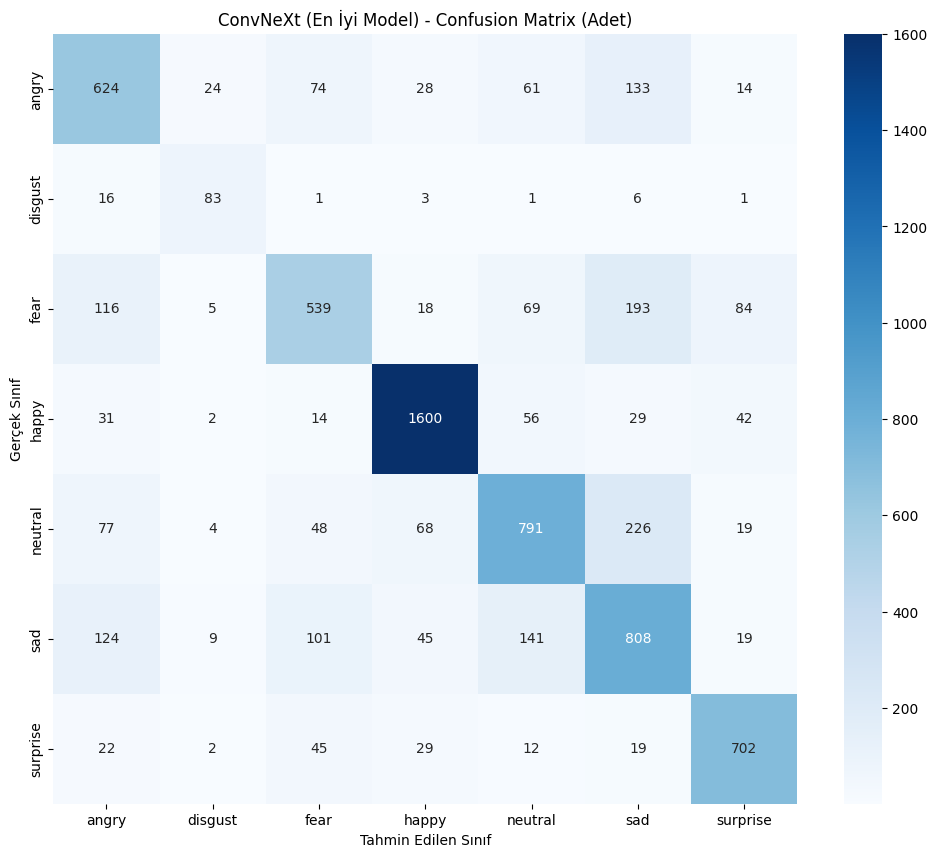


      DETAYLI SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

       angry       0.62      0.65      0.63       958
     disgust       0.64      0.75      0.69       111
        fear       0.66      0.53      0.58      1024
       happy       0.89      0.90      0.90      1774
     neutral       0.70      0.64      0.67      1233
         sad       0.57      0.65      0.61      1247
    surprise       0.80      0.84      0.82       831

    accuracy                           0.72      7178
   macro avg       0.70      0.71      0.70      7178
weighted avg       0.72      0.72      0.72      7178


Genel F1-Skoru (Weighted): %71.59

Tüm grafikler Kaggle sağ menüdeki 'Output' dizinine başarıyla kaydedildi.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
import os

def evaluate_all(history, model, dataloader, class_names):
    if history and len(history.get('train_loss', [])) > 0:
        epochs = range(1, len(history['train_loss']) + 1)
        
        plt.figure(figsize=(15, 6))

        # Loss Grafiği
        plt.subplot(1, 2, 1)
        plt.plot(epochs, history['train_loss'], 'r-o', markersize=4, label='Eğitim Kaybı')
        plt.plot(epochs, history['val_loss'], 'b-o', markersize=4, label='Doğrulama Kaybı')
        plt.title('Epoch Başına Kayıp (Loss)')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()

        # Accuracy Grafiği
        plt.subplot(1, 2, 2)
        plt.plot(epochs, history['train_acc'], 'r-o', markersize=4, label='Eğitim Başarısı')
        plt.plot(epochs, history['val_acc'], 'b-o', markersize=4, label='Doğrulama Başarısı')
        plt.title('Epoch Başına Doğruluk (Accuracy)')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()

        plt.savefig('/kaggle/working/convnext_egitim_grafikleri.png', dpi=300)
        plt.show()
        
    model.eval()
    all_preds = []
    all_labels = []

    print("\nTest seti üzerinde sonuçlar hesaplanıyor, lütfen bekleyin...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(12, 10))
    # fmt='d' ile KESİNLİKLE ADET olarak gösteriyoruz
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('ConvNeXt (En İyi Model) - Confusion Matrix (Adet)')
    plt.ylabel('Gerçek Sınıf')
    plt.xlabel('Tahmin Edilen Sınıf')

    plt.savefig('/kaggle/working/convnext_confusion_matrix_adet.png', dpi=300)
    plt.show()

    print("\n" + "="*40)
    print("      DETAYLI SINIFLANDIRMA RAPORU")
    print("="*40)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    final_f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"\nGenel F1-Skoru (Weighted): %{final_f1*100:.2f}")
    print("\nTüm grafikler Kaggle sağ menüdeki 'Output' dizinine başarıyla kaydedildi.")

print("\nEn iyi model ağırlıkları yükleniyor ve Çift GPU (T4x2) ayarlanıyor...")

# Modeli sıfırdan tanımlıyoruz (Ağırlıkları dosyadan çekeceğimiz için weights=None)
best_model = models.convnext_tiny(weights=None)
best_model.classifier[2] = nn.Linear(best_model.classifier[2].in_features, len(class_names))

# Kaydettiğimiz en iyi ağırlıkları (rekoru) yüklüyoruz
best_model_path = "/kaggle/working/convnext_best_model.pth"
if os.path.exists(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=device)
    # Eğitim sırasında module. ile kaydettiysek anahtar (key) uyumsuzluğunu çözer
    if 'model_state_dict' in checkpoint:
        best_model.load_state_dict(checkpoint['model_state_dict'])
    else:
        best_model.load_state_dict(checkpoint)
    print(">>> En iyi model (Rekor) başarıyla yüklendi!")
else:
    print("Uyarı: En iyi model dosyası bulunamadı, hafızadaki son modelle devam ediliyor.")
    best_model = model 

if torch.cuda.device_count() > 1:
    print(f">>> {torch.cuda.device_count()} adet GPU bulundu. DataParallel aktif edildi!")
    best_model = nn.DataParallel(best_model)
    
best_model = best_model.to(device)

# Fonksiyonu EN İYİ MODEL ve TEST SETİ ile çağırıp her şeyi tek seferde çizdiriyoruz
evaluate_all(history, best_model, test_loader, class_names)

**Neyi yanlış yapmış diye bakalım**

Modelin karıştırdığı görseller analiz ediliyor...


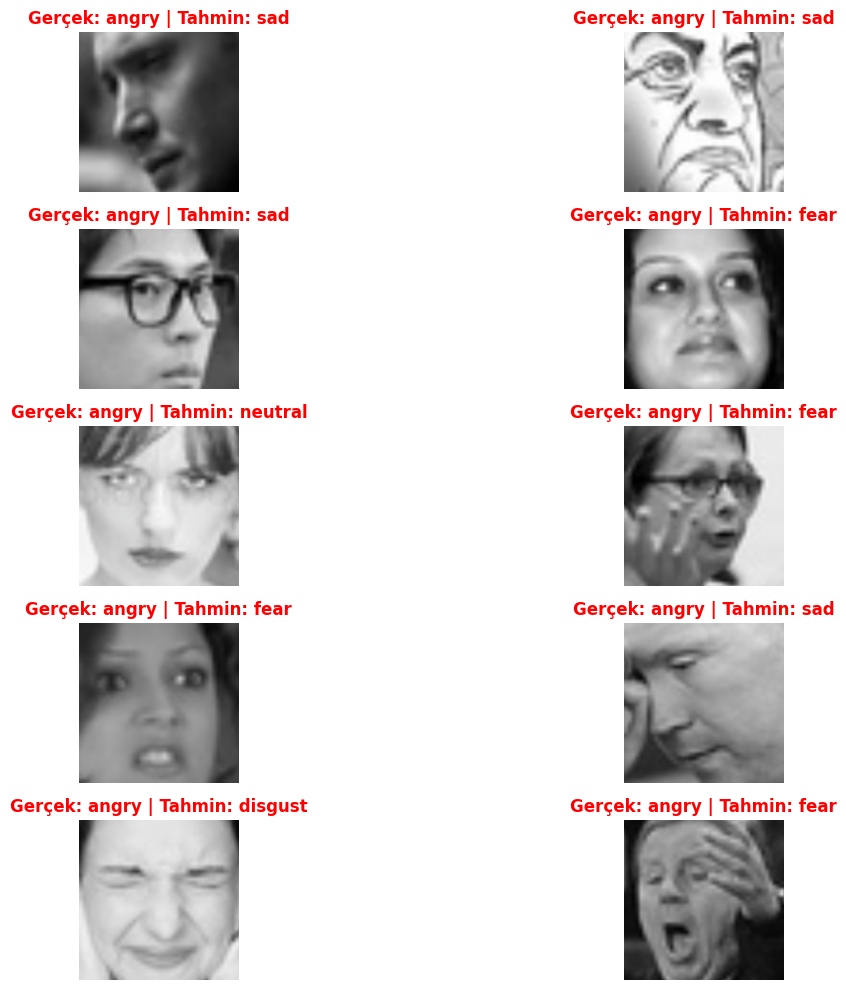

In [6]:
def visualize_convnext_mistakes(model, dataloader, class_names, num_images=10):
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                # Sadece YANLIŞ tahminleri yakalasın
                if preds[j] != labels[j]:
                    images_so_far += 1
                    ax = plt.subplot(num_images // 2, 2, images_so_far)
                    ax.axis('off')

                    # Normalizasyonu geri alıp resmi çizdirme
                    img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                    mean = np.array([0.485, 0.456, 0.406])
                    std = np.array([0.229, 0.224, 0.225])
                    img = std * img + mean
                    img = np.clip(img, 0, 1)

                    ax.imshow(img)
                    true_label = class_names[labels[j]]
                    pred_label = class_names[preds[j]]

                    ax.set_title(f'Gerçek: {true_label} | Tahmin: {pred_label}',
                                 color='red', fontsize=12, fontweight='bold')

                    if images_so_far == num_images:
                        plt.tight_layout()
                        # Hatalı tahminleri de Kaggle output'a kaydedelim
                        plt.savefig('/kaggle/working/convnext_hatali_tahminler.png', dpi=300)
                        plt.show()
                        return

# 10 tane hatalı örnek getirsin
print("Modelin karıştırdığı görseller analiz ediliyor...")
visualize_convnext_mistakes(model, test_loader, class_names, num_images=10)